<a href="https://colab.research.google.com/github/KatarinaNunes/Atividade_Disciplina/blob/main/Docking_FoldX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr


In [4]:
dock_path = '/content/drive/MyDrive/variants_mlep/pandadock_all_variants.csv'
foldx_path = '/content/drive/MyDrive/variants_mlep/Average_rnap_model_Repair.fxout'


In [5]:
# Docking
dock = pd.read_csv(dock_path)

# FoldX (pula o cabeçalho padrão do FoldX)
foldx = pd.read_csv(foldx_path, skiprows=8, sep='\t')


In [6]:
import re

def normalize_variant(variant):
    """
    Garante que todas as variantes estejam no formato:
    C:S456M
    """
    # Remove espaços
    variant = variant.strip()

    # Caso já tenha cadeia explícita (ex: AC1082S)
    if re.match(r'^[A-Z][A-Z]\d+[A-Z]$', variant):
        chain = variant[0]
        wt = variant[1]
        rest = variant[2:]
        return f"{chain}:{wt}{rest}"

    # Caso padrão sem cadeia (ex: SC456M)
    if re.match(r'^[A-Z]\d+[A-Z]$', variant[1:]):
        wt = variant[0]
        pos = re.findall(r'\d+', variant)[0]
        mut = variant[-1]
        return f"C:{wt}{pos}{mut}"

    return variant


In [7]:
dock['Variant_raw'] = dock['Variant']
dock['Variant'] = dock['Variant'].apply(normalize_variant)

dock[['Variant_raw', 'Variant']].drop_duplicates()


,Variant_raw,Variant
0,AC1082S,A:C1082S
50,G448D,G448D
100,H451Y,H451Y
150,N1111D,N1111D
200,S456L,S456L
250,S456M,S456M
300,T171N,T171N
350,T433I,T433I
400,WT,WT


In [8]:
dock_best = (
    dock
    .groupby('Variant', as_index=False)
    .agg(
        Best_Binding_Affinity=('Binding_Affinity', 'min'),
        Mean_Binding_Affinity=('Binding_Affinity', 'mean')
    )
)


In [9]:
foldx_energy = foldx[['Pdb', 'total energy']].copy()
foldx_energy.rename(columns={'total energy': 'FoldX_DeltaG'}, inplace=True)


In [10]:
import pandas as pd

dock_path = '/content/drive/MyDrive/variants_mlep/pandadock_all_variants.csv'
dock = pd.read_csv(dock_path)

dock.columns.tolist()


['Rank',
 'Pose_ID',
 'Score',
 'Energy',
 'Binding_Affinity',
 'IC50_uM',
 'EC50_uM',
 'Ligand_Efficiency',
 'VdW_Energy',
 'Electrostatic_Energy',
 'HBond_Energy',
 'Hydrophobic_Energy',
 'Solvation_Energy',
 'Entropy_Energy',
 'Clash_Score',
 'HBond_Count',
 'Hydrophobic_Count',
 'Salt_Bridge_Count',
 'Variant']

In [11]:
import re

# possíveis nomes comuns
candidates = [
    'Variant','variant','VARIANT',
    'Mutation','mutation','MUTATION',
    'Mut','mut','mutant',
    'Substitution','substitution',
    'Name','name','ID','id'
]

variant_col = None
for c in candidates:
    if c in dock.columns:
        variant_col = c
        break

# fallback: procurar coluna que "parece" conter coisas tipo SC456M / AC1082S
if variant_col is None:
    pattern = re.compile(r'^[A-Z]{1,2}[A-Z]\d+[A-Z]$')  # SC456M ou AC1082S
    scores = {}
    for c in dock.columns:
        vals = dock[c].dropna().astype(str).head(200)
        if len(vals) == 0:
            continue
        scores[c] = sum(bool(pattern.match(v.strip())) for v in vals)
    if scores:
        variant_col = max(scores, key=scores.get)

print("Coluna de variante detectada:", variant_col)


Coluna de variante detectada: Variant


In [12]:
import re

def normalize_variant(variant):
    variant = str(variant).strip()

    # caso: AC1082S (cadeia explícita como 2 letras? Ex: A C1082S -> na verdade é "A"+"C1082S")
    if re.match(r'^[A-Z][A-Z]\d+[A-Z]$', variant):
        chain = variant[0]
        wt = variant[1]
        rest = variant[2:]
        return f"{chain}:{wt}{rest}"

    # caso: SC456M (sem cadeia, queremos forçar C:)
    if re.match(r'^[A-Z][A-Z]?\d+[A-Z]$', variant):
        # Ex: SC456M -> wt=S pos=456 mut=M (cadeia=C)
        wt = variant[0]
        pos = re.findall(r'\d+', variant)[0]
        mut = variant[-1]
        return f"C:{wt}{pos}{mut}"

    return variant

dock['Variant_raw'] = dock[variant_col]
dock['Variant'] = dock[variant_col].apply(normalize_variant)

dock[['Variant_raw', 'Variant']].drop_duplicates().head(20)


,Variant_raw,Variant
0,AC1082S,A:C1082S
50,G448D,C:G448D
100,H451Y,C:H451Y
150,N1111D,C:N1111D
200,S456L,C:S456L
250,S456M,C:S456M
300,T171N,C:T171N
350,T433I,C:T433I
400,WT,WT


In [13]:
import pandas as pd
import numpy as np
import re

dock_path  = '/content/drive/MyDrive/variants_mlep/pandadock_all_variants.csv'
foldx_path = '/content/drive/MyDrive/variants_mlep/Average_rnap_model_Repair.fxout'

dock = pd.read_csv(dock_path)

print("Colunas no docking:")
print(dock.columns.tolist())
print("\nPrimeiras linhas:")
display(dock.head(3))

def detect_variant_col(df):
    # nomes comuns
    candidates = ['Variant','variant','Mutation','mutation','Mut','mut','Substitution','Name','ID','id']
    for c in candidates:
        if c in df.columns:
            return c

    # fallback: coluna que mais parece conter strings tipo SC456M / AC1082S
    pattern = re.compile(r'^[A-Z]{1,2}[A-Z]\d+[A-Z]$')
    best_col, best_score = None, -1
    for c in df.columns:
        vals = df[c].dropna().astype(str).head(300)
        score = sum(bool(pattern.match(v.strip())) for v in vals)
        if score > best_score:
            best_col, best_score = c, score
    return best_col

def detect_affinity_col(df):
    # tenta achar colunas numéricas que tenham "affinity"/"score"/"vina" etc no nome
    name_hits = []
    for c in df.columns:
        cl = c.lower()
        if any(k in cl for k in ['affinity','binding','vina','score','energy','delta','dg']):
            name_hits.append(c)

    # prioriza as que são numéricas
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    for c in name_hits:
        if c in numeric_cols:
            return c

    # fallback: escolher a coluna numérica mais "variável" (evita colunas constantes/IDs)
    if numeric_cols:
        variances = {c: np.nanvar(df[c].values) for c in numeric_cols}
        return max(variances, key=variances.get)

    return None

variant_col  = detect_variant_col(dock)
affinity_col = detect_affinity_col(dock)

print("\nDetectado:")
print(" - Coluna de variante:", variant_col)
print(" - Coluna de afinidade/score:", affinity_col)


Colunas no docking:
['Rank', 'Pose_ID', 'Score', 'Energy', 'Binding_Affinity', 'IC50_uM', 'EC50_uM', 'Ligand_Efficiency', 'VdW_Energy', 'Electrostatic_Energy', 'HBond_Energy', 'Hydrophobic_Energy', 'Solvation_Energy', 'Entropy_Energy', 'Clash_Score', 'HBond_Count', 'Hydrophobic_Count', 'Salt_Bridge_Count', 'Variant']

Primeiras linhas:


,Rank,Pose_ID,Score,Energy,Binding_Affinity,IC50_uM,EC50_uM,Ligand_Efficiency,VdW_Energy,Electrostatic_Energy,HBond_Energy,Hydrophobic_Energy,Solvation_Energy,Entropy_Energy,Clash_Score,HBond_Count,Hydrophobic_Count,Salt_Bridge_Count,Variant
0,1.0,pose_1,12.348674,-12.348674,-7.409204,3.70,37.0,-0.063327,0.074944,0.0,-6.0,-4.0,0.0,0.0,122.688277,0.0,0.0,0.0,AC1082S
1,2.0,pose_2,12.506461,-12.506461,-7.503877,3.16,31.6,-0.064136,0.075629,0.0,-6.0,-4.0,0.0,0.0,119.227255,0.0,0.0,0.0,AC1082S
2,3.0,pose_3,12.768492,-12.768492,-7.661095,2.42,24.2,-0.065479,0.075192,0.0,-6.0,-4.0,0.0,0.0,123.230790,0.0,0.0,0.0,AC1082S



Detectado:
 - Coluna de variante: Variant
 - Coluna de afinidade/score: Score


In [14]:
def normalize_to_chainC(v):
    v = str(v).strip()

    # Se vier no formato "C:S456M" já, mantém
    if re.match(r'^[A-Z]:[A-Z]\d+[A-Z]$', v):
        return v

    # Se vier no formato "AC1082S" (cadeia explícita pela primeira letra),
    # mas você quer tratar tudo como cadeia C:
    if re.match(r'^[A-Z][A-Z]\d+[A-Z]$', v):
        wt = v[1]                 # A C1082S -> wt = C (na verdade wt está na segunda letra)
        pos = re.findall(r'\d+', v)[0]
        mut = v[-1]
        # aqui sua convenção de variante que você lista é tipo AC1082S (wt=A?),
        # então vamos usar sempre o 1º AA como WT se estiver nesse padrão "AC1082S":
        wt = v[0]
        pos = re.findall(r'\d+', v)[0]
        mut = v[-1]
        return f"C:{wt}{pos}{mut}"

    # Caso típico "SC456M" -> WT=S pos=456 MUT=M
    if re.match(r'^[A-Z]\d+[A-Z]$', v[1:]) or re.match(r'^[A-Z]\d+[A-Z]$', v):
        wt = v[0]
        pos = re.findall(r'\d+', v)[0]
        mut = v[-1]
        return f"C:{wt}{pos}{mut}"

    # fallback: tenta extrair AA/pos/AA de qualquer coisa parecida
    m = re.search(r'([A-Z])(\d+)([A-Z])', v)
    if m:
        wt, pos, mut = m.group(1), m.group(2), m.group(3)
        return f"C:{wt}{pos}{mut}"

    return v

dock['Variant_raw'] = dock[variant_col]
dock['Variant'] = dock[variant_col].apply(normalize_to_chainC)

dock[['Variant_raw','Variant']].drop_duplicates().head(20)


,Variant_raw,Variant
0,AC1082S,C:A1082S
50,G448D,C:G448D
100,H451Y,C:H451Y
150,N1111D,C:N1111D
200,S456L,C:S456L
250,S456M,C:S456M
300,T171N,C:T171N
350,T433I,C:T433I
400,WT,WT


In [15]:
# garante afinidade numérica
dock[affinity_col] = pd.to_numeric(dock[affinity_col], errors='coerce')

dock_best = (
    dock.dropna(subset=[affinity_col])
        .groupby('Variant', as_index=False)
        .agg(
            Best_Binding_Affinity=(affinity_col, 'min'),
            Mean_Binding_Affinity=(affinity_col, 'mean'),
            N_poses=(affinity_col, 'count')
        )
)

dock_best.sort_values('Best_Binding_Affinity').head(10)


,Variant,Best_Binding_Affinity,Mean_Binding_Affinity,N_poses
0,C:A1082S,12.348674,13.464659,50
8,WT,12.366067,13.448213,50
4,C:S456L,12.454222,13.499880,50
1,C:G448D,12.488683,13.357583,50
3,C:N1111D,12.570234,13.496269,50
6,C:T171N,12.602413,13.447810,50
7,C:T433I,12.658140,13.509774,50
5,C:S456M,12.704805,13.452571,50
2,C:H451Y,12.753795,13.422410,50


In [16]:
# ====== FULL FIX: FoldX Variant order mapping (robust) ======
import re
import pandas as pd

# --- Your declared variant order (as given) ---
variants_order = [
    'SC456M','SC456L','NC1111D','AC1082S',
    'HC451Y','GC448D','TC433I','TC171N'
]

def to_chainC(v: str) -> str:
    """
    Converts strings like 'SC456M' or 'AC1082S;' into 'C:S456M' / 'C:A1082S'
    Assumes everything refers to chain C (your clarification).
    """
    v = str(v).strip().replace(';', '')
    m = re.search(r'(\d+)', v)
    if not m:
        raise ValueError(f"Could not find numeric position in variant: {v}")
    pos = m.group(1)
    wt = v[0]
    mut = v[-1]
    return f"C:{wt}{pos}{mut}"

# Normalized order used for consistent merges
order_norm = [to_chainC(v) for v in variants_order]
print("Normalized variant order:", order_norm)

# ====== Read FoldX .fxout (already loaded as `foldx` in your notebook) ======
# If you haven't loaded it yet, uncomment and set the correct path:
# foldx_path = '/content/drive/MyDrive/Average_rnap_model_Repair.fxout'
# foldx = pd.read_csv(foldx_path, skiprows=8, sep='\t')

# Detect FoldX total energy column safely
foldx_energy_col = None
for c in foldx.columns:
    if 'total' in c.lower() and 'energy' in c.lower():
        foldx_energy_col = c
        break
if foldx_energy_col is None:
    numeric_cols = [c for c in foldx.columns if pd.api.types.is_numeric_dtype(foldx[c])]
    if not numeric_cols:
        raise ValueError("No numeric columns found in FoldX output; cannot detect energy column.")
    foldx_energy_col = numeric_cols[0]

print("FoldX energy column detected:", foldx_energy_col)
print("FoldX rows:", foldx.shape[0])

# Build FoldX energy table aligned to your order
foldx_energy = foldx[[foldx_energy_col]].copy()
foldx_energy.rename(columns={foldx_energy_col: 'FoldX_DeltaG'}, inplace=True)

# Use the first N rows (N = number of variants in your order)
N = len(order_norm)
if foldx_energy.shape[0] < N:
    raise ValueError(f"FoldX file has only {foldx_energy.shape[0]} rows, but {N} variants were expected.")

foldx_energy = foldx_energy.iloc[:N].copy()
foldx_energy['Variant'] = order_norm

display(foldx_energy)

# ====== Merge with docking summary (assumes you already created dock_best with 'Variant') ======
# If `dock_best` isn't created yet, stop here and create it first.
df_compare = pd.merge(
    dock_best,
    foldx_energy[['Variant', 'FoldX_DeltaG']],
    on='Variant',
    how='inner'
)

# Enforce your variant order
df_compare['Variant'] = pd.Categorical(df_compare['Variant'], categories=order_norm, ordered=True)
df_compare = df_compare.sort_values('Variant')

display(df_compare)


Normalized variant order: ['C:S456M', 'C:S456L', 'C:N1111D', 'C:A1082S', 'C:H451Y', 'C:G448D', 'C:T433I', 'C:T171N']
FoldX energy column detected: total energy
FoldX rows: 8


,FoldX_DeltaG,Variant
0,-3.105210,C:S456M
1,-2.645280,C:S456L
2,1.716340,C:N1111D
3,0.960188,C:A1082S
4,0.937503,C:H451Y
5,3.812380,C:G448D
6,-0.042985,C:T433I
7,0.194367,C:T171N


,Variant,Best_Binding_Affinity,Mean_Binding_Affinity,N_poses,FoldX_DeltaG
5,C:S456M,12.704805,13.452571,50,-3.105210
4,C:S456L,12.454222,13.499880,50,-2.645280
3,C:N1111D,12.570234,13.496269,50,1.716340
0,C:A1082S,12.348674,13.464659,50,0.960188
2,C:H451Y,12.753795,13.422410,50,0.937503
1,C:G448D,12.488683,13.357583,50,3.812380
7,C:T433I,12.658140,13.509774,50,-0.042985
6,C:T171N,12.602413,13.447810,50,0.194367


df_compare shape: (8, 5)


,Variant,Best_Binding_Affinity,Mean_Binding_Affinity,N_poses,FoldX_DeltaG
5,C:S456M,12.704805,13.452571,50,-3.105210
4,C:S456L,12.454222,13.499880,50,-2.645280
3,C:N1111D,12.570234,13.496269,50,1.716340
0,C:A1082S,12.348674,13.464659,50,0.960188
2,C:H451Y,12.753795,13.422410,50,0.937503
1,C:G448D,12.488683,13.357583,50,3.812380
7,C:T433I,12.658140,13.509774,50,-0.042985
6,C:T171N,12.602413,13.447810,50,0.194367


Rows after dropping NaNs: 8
Spearman rho = -0.357 | p = 0.385


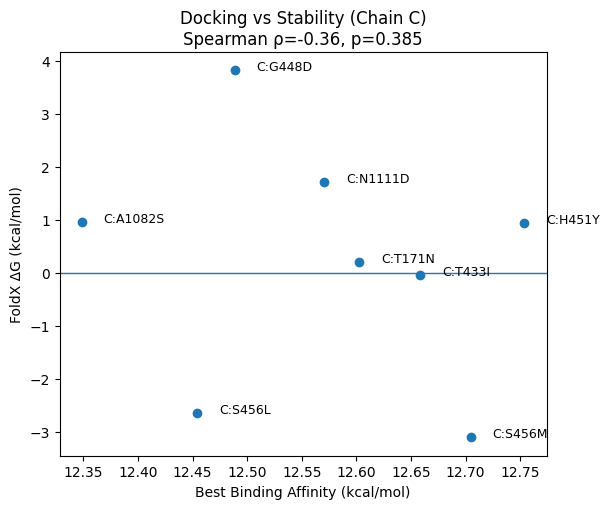

[Mean affinity] Spearman rho = -0.429 | p = 0.289


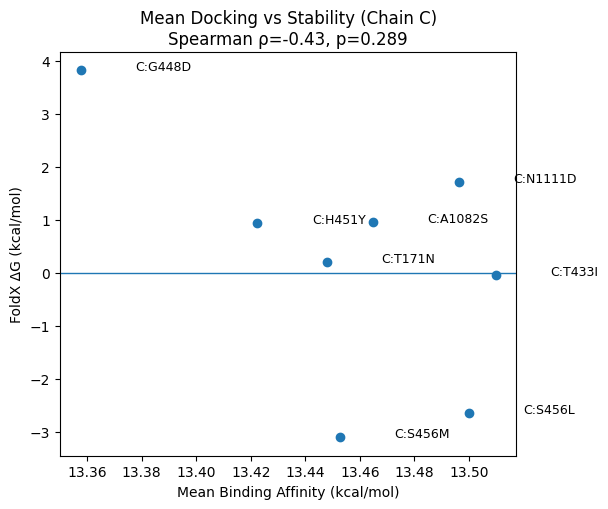

Saved: /content/drive/MyDrive/docking_vs_foldx_comparison.xlsx


In [17]:
# ====== CONTINUE: correlation + publication-style plot + export ======
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# --- sanity checks ---
print("df_compare shape:", df_compare.shape)
display(df_compare)

needed = ['Variant', 'Best_Binding_Affinity', 'FoldX_DeltaG']
missing = [c for c in needed if c not in df_compare.columns]
if missing:
    raise ValueError(f"Missing required columns in df_compare: {missing}")

# Ensure numeric
df_compare['Best_Binding_Affinity'] = pd.to_numeric(df_compare['Best_Binding_Affinity'], errors='coerce')
df_compare['FoldX_DeltaG'] = pd.to_numeric(df_compare['FoldX_DeltaG'], errors='coerce')

df_clean = df_compare.dropna(subset=['Best_Binding_Affinity', 'FoldX_DeltaG']).copy()
print("Rows after dropping NaNs:", df_clean.shape[0])

# --- Spearman correlation (robust for non-linear / small n) ---
rho, pval = spearmanr(df_clean['Best_Binding_Affinity'], df_clean['FoldX_DeltaG'])
print(f"Spearman rho = {rho:.3f} | p = {pval:.3g}")

# --- Plot: Docking vs FoldX (neutral, publication-friendly) ---
plt.figure(figsize=(6.2, 5.2))
plt.scatter(df_clean['Best_Binding_Affinity'], df_clean['FoldX_DeltaG'])

# label points (slight offset)
for _, r in df_clean.iterrows():
    plt.text(
        r['Best_Binding_Affinity'] + 0.02,
        r['FoldX_DeltaG'],
        str(r['Variant']),
        fontsize=9
    )

plt.axhline(0, linewidth=1)   # ΔG reference line (optional but useful)
plt.xlabel('Best Binding Affinity (kcal/mol)')
plt.ylabel('FoldX ΔG (kcal/mol)')
plt.title(f'Docking vs Stability (Chain C)\nSpearman ρ={rho:.2f}, p={pval:.3g}')
plt.tight_layout()
plt.show()

# --- Optional: also plot Mean_Binding_Affinity vs FoldX if you want ---
if 'Mean_Binding_Affinity' in df_clean.columns:
    rho2, pval2 = spearmanr(df_clean['Mean_Binding_Affinity'], df_clean['FoldX_DeltaG'])
    print(f"[Mean affinity] Spearman rho = {rho2:.3f} | p = {pval2:.3g}")

    plt.figure(figsize=(6.2, 5.2))
    plt.scatter(df_clean['Mean_Binding_Affinity'], df_clean['FoldX_DeltaG'])
    for _, r in df_clean.iterrows():
        plt.text(r['Mean_Binding_Affinity'] + 0.02, r['FoldX_DeltaG'], str(r['Variant']), fontsize=9)
    plt.axhline(0, linewidth=1)
    plt.xlabel('Mean Binding Affinity (kcal/mol)')
    plt.ylabel('FoldX ΔG (kcal/mol)')
    plt.title(f'Mean Docking vs Stability (Chain C)\nSpearman ρ={rho2:.2f}, p={pval2:.3g}')
    plt.tight_layout()
    plt.show()

# --- Export results to Excel (nice for supplement / thesis) ---
out_xlsx = '/content/drive/MyDrive/docking_vs_foldx_comparison.xlsx'
with pd.ExcelWriter(out_xlsx, engine='openpyxl') as writer:
    df_compare.to_excel(writer, index=False, sheet_name='Docking_vs_FoldX')
    # also export per-pose raw docking (optional, can be large)
    # dock.to_excel(writer, index=False, sheet_name='Docking_raw')
print("Saved:", out_xlsx)


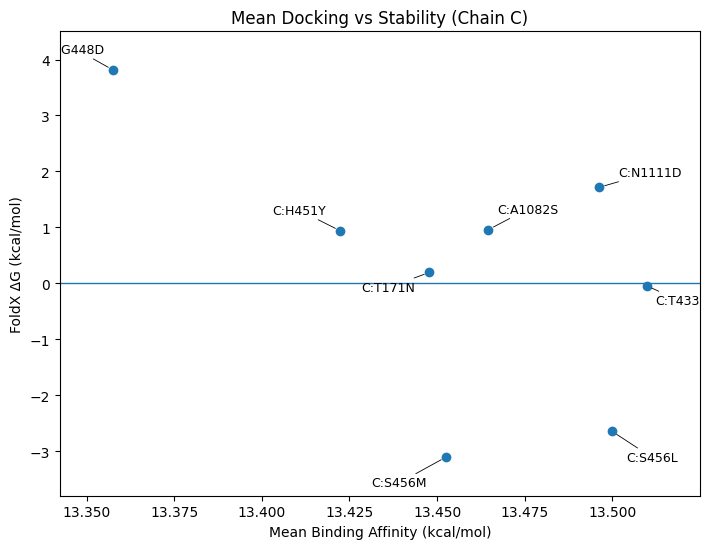

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# df_clean precisa ter: Variant, Mean_Binding_Affinity (ou Best_Binding_Affinity), FoldX_DeltaG
xcol = 'Mean_Binding_Affinity'  # troque pra 'Best_Binding_Affinity' se preferir
ycol = 'FoldX_DeltaG'

x = df_clean[xcol].astype(float).values
y = df_clean[ycol].astype(float).values
labels = df_clean['Variant'].astype(str).values

fig, ax = plt.subplots(figsize=(7.2, 5.6))
ax.scatter(x, y)

# Linha de referência ΔG=0
ax.axhline(0, linewidth=1)

# Margens (evita cortar labels)
xmin, xmax = np.min(x), np.max(x)
ymin, ymax = np.min(y), np.max(y)
xpad = (xmax - xmin) * 0.10 if xmax > xmin else 0.2
ypad = (ymax - ymin) * 0.10 if ymax > ymin else 0.2
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

# Centro (para definir quadrantes e jogar o texto "pra fora")
xmid = np.median(x)
ymid = np.median(y)

# Offsets automáticos por quadrante + leve jitter determinístico
for i, (xi, yi, lab) in enumerate(zip(x, y, labels)):
    # direção: se está à esquerda do centro, joga texto pra esquerda; se à direita, pra direita
    dx = -10 if xi < xmid else 10
    dy = -10 if yi < ymid else 10

    # jitter pequeno pra reduzir colisão (determinístico)
    dx += (i % 3 - 1) * 4
    dy += ((i // 3) % 3 - 1) * 4

    ax.annotate(
        lab,
        (xi, yi),
        xytext=(dx, dy),
        textcoords='offset points',
        ha='right' if dx < 0 else 'left',
        va='top' if dy < 0 else 'bottom',
        fontsize=9,
        clip_on=True,
        arrowprops=dict(arrowstyle='-', lw=0.6, shrinkA=0, shrinkB=4)
    )

ax.set_xlabel(f'{xcol.replace("_"," ")} (kcal/mol)')
ax.set_ylabel('FoldX ΔG (kcal/mol)')
ax.set_title('Mean Docking vs Stability (Chain C)')
plt.tight_layout()
plt.show()


In [19]:
!pip install adjustText


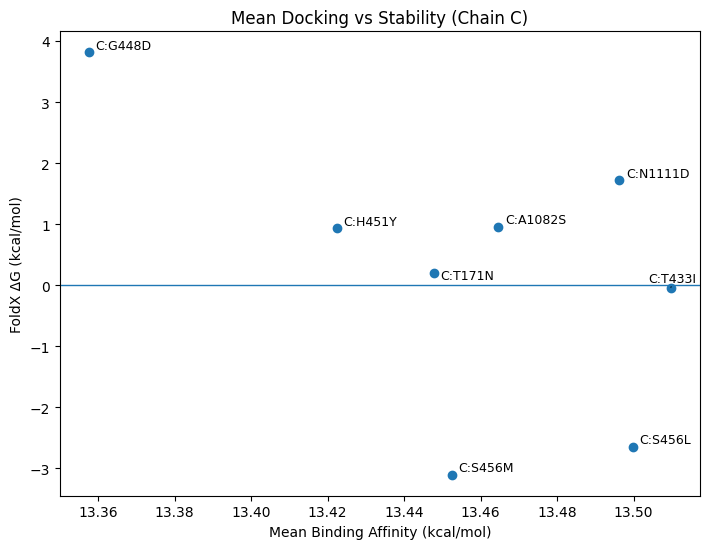

In [20]:
from adjustText import adjust_text
import matplotlib.pyplot as plt

xcol = 'Mean_Binding_Affinity'
ycol = 'FoldX_DeltaG'

fig, ax = plt.subplots(figsize=(7.2, 5.6))
ax.scatter(df_clean[xcol], df_clean[ycol])
ax.axhline(0, linewidth=1)

texts = []
for xi, yi, lab in zip(df_clean[xcol], df_clean[ycol], df_clean['Variant']):
    texts.append(ax.text(xi, yi, str(lab), fontsize=9))

adjust_text(
    texts, ax=ax,
    arrowprops=dict(arrowstyle='-', lw=0.6)
)

ax.set_xlabel(f'{xcol.replace("_"," ")} (kcal/mol)')
ax.set_ylabel('FoldX ΔG (kcal/mol)')
ax.set_title('Mean Docking vs Stability (Chain C)')
plt.tight_layout()
plt.show()


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)

# ====== PATHS (adjust if needed) ======
OUTDIR = '/content/drive/MyDrive/docking_foldx_outputs'
TABLE_OUT = f'{OUTDIR}/docking_foldx_comparison.xlsx'

SCATTER_BEST_OUT = f'{OUTDIR}/scatter_best_docking_foldx.png'
SCATTER_MEAN_OUT = f'{OUTDIR}/scatter_mean_docking_foldx.png'
HEATMAP_OUT = f'{OUTDIR}/heatmap_spearman_docking_foldx.png'
PCA2D_OUT = f'{OUTDIR}/pca_2d_docking_foldx.png'
PCA3D_OUT = f'{OUTDIR}/pca_3d_docking_foldx.png'

import os
os.makedirs(OUTDIR, exist_ok=True)

# Expect df_clean already created from previous steps
required_cols = ['Variant', 'Best_Binding_Affinity', 'Mean_Binding_Affinity', 'FoldX_DeltaG']
missing = [c for c in required_cols if c not in df_clean.columns]
if missing:
    raise ValueError(f"df_clean missing required columns: {missing}")

df_clean = df_clean.copy()
df_clean['Variant_short'] = df_clean['Variant'].astype(str).str.replace('C:', '', regex=False)

# Ensure numeric
for c in ['Best_Binding_Affinity', 'Mean_Binding_Affinity', 'FoldX_DeltaG']:
    df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')

df_clean = df_clean.dropna(subset=['Best_Binding_Affinity', 'Mean_Binding_Affinity', 'FoldX_DeltaG'])
df_clean


,Variant,Best_Binding_Affinity,Mean_Binding_Affinity,N_poses,FoldX_DeltaG,Variant_short
5,C:S456M,12.704805,13.452571,50,-3.105210,S456M
4,C:S456L,12.454222,13.499880,50,-2.645280,S456L
3,C:N1111D,12.570234,13.496269,50,1.716340,N1111D
0,C:A1082S,12.348674,13.464659,50,0.960188,A1082S
2,C:H451Y,12.753795,13.422410,50,0.937503,H451Y
1,C:G448D,12.488683,13.357583,50,3.812380,G448D
7,C:T433I,12.658140,13.509774,50,-0.042985,T433I
6,C:T171N,12.602413,13.447810,50,0.194367,T171N


In [22]:
df_clean.to_excel(TABLE_OUT, index=False)
print("Saved table:", TABLE_OUT)


Saved table: /content/drive/MyDrive/docking_foldx_outputs/docking_foldx_comparison.xlsx


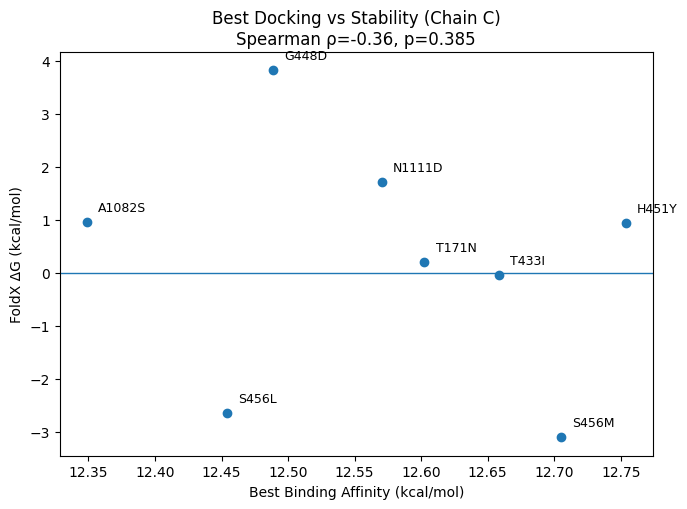

Saved plot: /content/drive/MyDrive/docking_foldx_outputs/scatter_best_docking_foldx.png


In [23]:
xcol, ycol = 'Best_Binding_Affinity', 'FoldX_DeltaG'

rho, pval = spearmanr(df_clean[xcol], df_clean[ycol])

plt.figure(figsize=(7,5.2))
plt.scatter(df_clean[xcol], df_clean[ycol])
plt.axhline(0, linewidth=1)

for _, r in df_clean.iterrows():
    plt.annotate(
        r['Variant_short'],
        (r[xcol], r[ycol]),
        textcoords='offset points',
        xytext=(8,8),
        fontsize=9
    )

plt.xlabel('Best Binding Affinity (kcal/mol)')
plt.ylabel('FoldX ΔG (kcal/mol)')
plt.title(f'Best Docking vs Stability (Chain C)\nSpearman ρ={rho:.2f}, p={pval:.3g}')
plt.tight_layout()
plt.savefig(SCATTER_BEST_OUT, dpi=300)
plt.show()

print("Saved plot:", SCATTER_BEST_OUT)


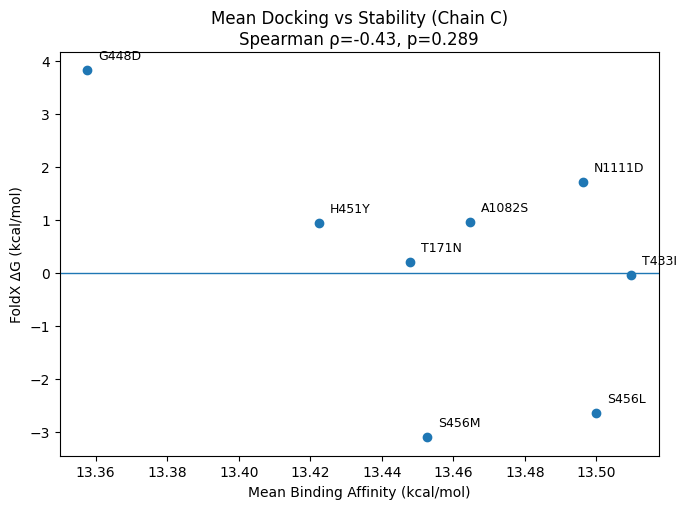

Saved plot: /content/drive/MyDrive/docking_foldx_outputs/scatter_mean_docking_foldx.png


In [24]:
xcol, ycol = 'Mean_Binding_Affinity', 'FoldX_DeltaG'

rho, pval = spearmanr(df_clean[xcol], df_clean[ycol])

plt.figure(figsize=(7,5.2))
plt.scatter(df_clean[xcol], df_clean[ycol])
plt.axhline(0, linewidth=1)

for _, r in df_clean.iterrows():
    plt.annotate(
        r['Variant_short'],
        (r[xcol], r[ycol]),
        textcoords='offset points',
        xytext=(8,8),
        fontsize=9
    )

plt.xlabel('Mean Binding Affinity (kcal/mol)')
plt.ylabel('FoldX ΔG (kcal/mol)')
plt.title(f'Mean Docking vs Stability (Chain C)\nSpearman ρ={rho:.2f}, p={pval:.3g}')
plt.tight_layout()
plt.savefig(SCATTER_MEAN_OUT, dpi=300)
plt.show()

print("Saved plot:", SCATTER_MEAN_OUT)


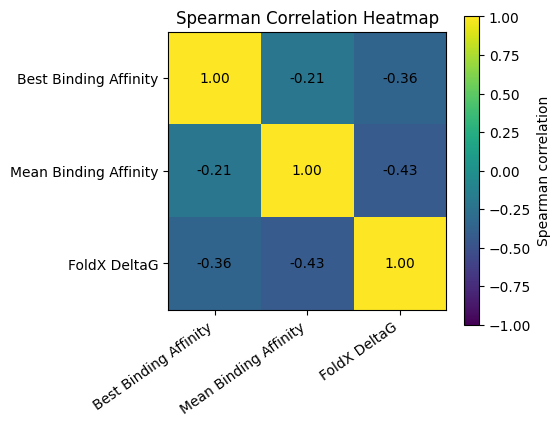

Saved plot: /content/drive/MyDrive/docking_foldx_outputs/heatmap_spearman_docking_foldx.png


In [25]:
cols = ['Best_Binding_Affinity', 'Mean_Binding_Affinity', 'FoldX_DeltaG']
corr = df_clean[cols].corr(method='spearman').values

fig, ax = plt.subplots(figsize=(5.6,4.6))
im = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels([c.replace('_',' ') for c in cols], rotation=35, ha='right')
ax.set_yticklabels([c.replace('_',' ') for c in cols])

# annotate values
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr[i,j]:.2f}", ha='center', va='center', fontsize=10)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Spearman correlation')

ax.set_title('Spearman Correlation Heatmap')
plt.tight_layout()
plt.savefig(HEATMAP_OUT, dpi=300)
plt.show()

print("Saved plot:", HEATMAP_OUT)


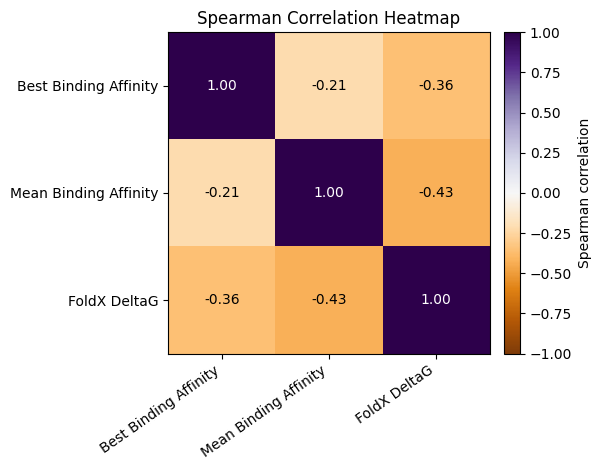

Saved plot: /content/drive/MyDrive/docking_foldx_outputs/heatmap_spearman_docking_foldx.png


In [26]:
# =========================
# HEATMAP ROBUSTO (SPEARMAN) — PALETA ROXO ↔ LARANJA
# =========================

cols = ['Best_Binding_Affinity', 'Mean_Binding_Affinity', 'FoldX_DeltaG']
corr = df_clean[cols].corr(method='spearman').values

fig, ax = plt.subplots(figsize=(5.8,4.8))

im = ax.imshow(
    corr,
    cmap='PuOr',     # 🎨 roxo ↔ laranja (divergente)
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels([c.replace('_',' ') for c in cols], rotation=35, ha='right')
ax.set_yticklabels([c.replace('_',' ') for c in cols])

# Anotação com contraste automático
for i in range(len(cols)):
    for j in range(len(cols)):
        val = corr[i, j]
        txt_color = 'white' if abs(val) > 0.55 else 'black'
        ax.text(
            j, i,
            f"{val:.2f}",
            ha='center',
            va='center',
            fontsize=10,
            color=txt_color
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Spearman correlation')

ax.set_title('Spearman Correlation Heatmap')
plt.tight_layout()
plt.savefig(HEATMAP_OUT, dpi=300)
plt.show()

print("Saved plot:", HEATMAP_OUT)


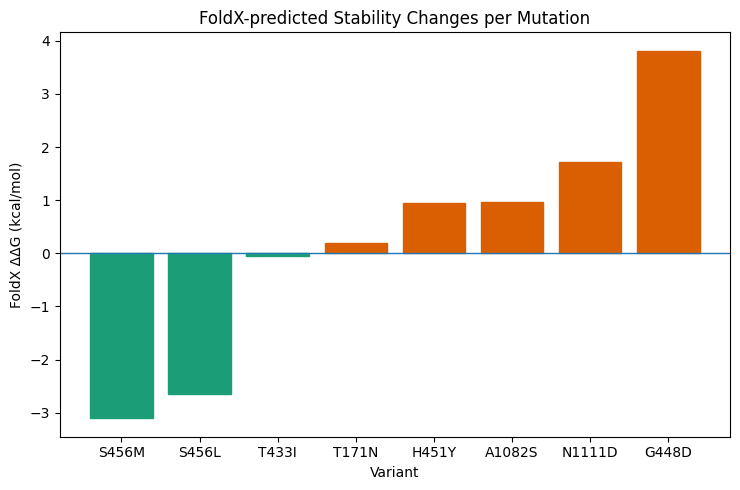

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# ordenar por ΔΔG
df_fx = df_clean.sort_values('FoldX_DeltaG')

plt.figure(figsize=(7.5,5))
bars = plt.bar(
    df_fx['Variant_short'],
    df_fx['FoldX_DeltaG']
)

# linha de referência
plt.axhline(0, linewidth=1)

# colorir por sinal
for bar, val in zip(bars, df_fx['FoldX_DeltaG']):
    bar.set_color('#d95f02' if val > 0 else '#1b9e77')  # laranja = desestab | verde = estab

plt.ylabel('FoldX ΔΔG (kcal/mol)')
plt.xlabel('Variant')
plt.title('FoldX-predicted Stability Changes per Mutation')

plt.tight_layout()
plt.show()


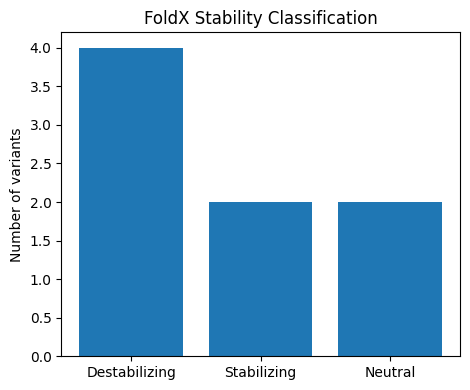

,count
FoldX_class,
Destabilizing,4
Stabilizing,2
Neutral,2


In [28]:
def classify_foldx(ddg, thr=0.5):
    if ddg > thr:
        return 'Destabilizing'
    elif ddg < -thr:
        return 'Stabilizing'
    else:
        return 'Neutral'

df_fx['FoldX_class'] = df_fx['FoldX_DeltaG'].apply(classify_foldx)

counts = df_fx['FoldX_class'].value_counts()

plt.figure(figsize=(4.8,4))
plt.bar(counts.index, counts.values)

plt.ylabel('Number of variants')
plt.title('FoldX Stability Classification')
plt.tight_layout()
plt.show()

counts


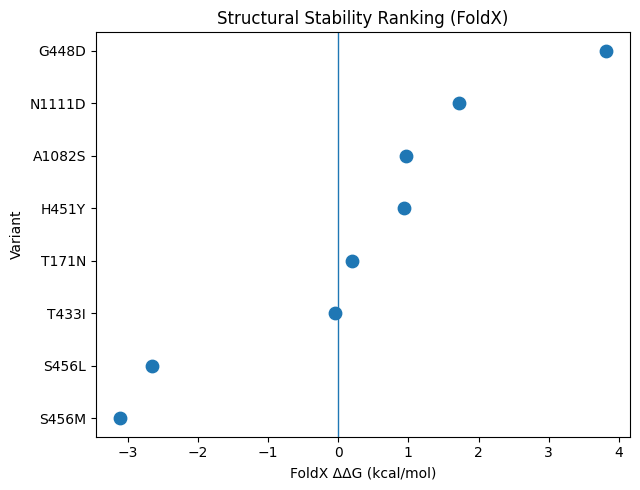

In [29]:
plt.figure(figsize=(6.5,5))
plt.scatter(
    df_fx['FoldX_DeltaG'],
    df_fx['Variant_short'],
    s=80
)

plt.axvline(0, linewidth=1)
plt.xlabel('FoldX ΔΔG (kcal/mol)')
plt.ylabel('Variant')
plt.title('Structural Stability Ranking (FoldX)')
plt.tight_layout()
plt.show()


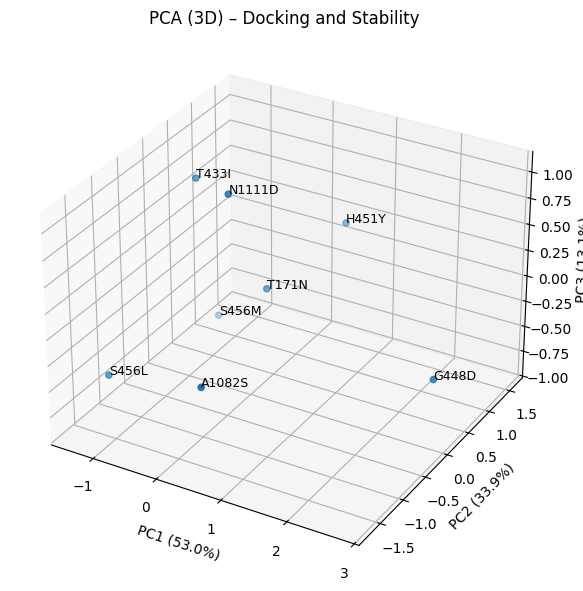

Saved plot: /content/drive/MyDrive/docking_foldx_outputs/pca_3d_docking_foldx.png


In [30]:
features = ['Best_Binding_Affinity', 'Mean_Binding_Affinity', 'FoldX_DeltaG']
X = df_clean[features].values
X_scaled = StandardScaler().fit_transform(X)

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2])

for i, var in enumerate(df_clean['Variant_short'].values):
    ax.text(X_pca3[i,0], X_pca3[i,1], X_pca3[i,2], var, fontsize=9)

ax.set_xlabel(f'PC1 ({pca3.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca3.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca3.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('PCA (3D) – Docking and Stability')

plt.tight_layout()
plt.savefig(PCA3D_OUT, dpi=300)
plt.show()

print("Saved plot:", PCA3D_OUT)
